# Ensemble Learning 重點筆記

> 這份筆記整理了 **Bagging、Boosting、Stacking、Random Forest** 的核心概念，適合放在 Jupyter Notebook 當複習用。

## 1. 先講結論

**Ensemble learning** 的核心想法是：

> 把多個模型組合起來，得到比單一模型更穩定、更泛化的結果。

常見三大類：

1. **Bagging**：大家各自訓練，最後投票或平均  
2. **Boosting**：前一個模型犯的錯，後一個模型接著修  
3. **Stacking**：再訓練一個模型，學會怎麼整合前面多個模型的輸出

## 2. 弱學習器（Weak Learner）是什麼？

弱學習器不是固定指某一種模型，而是指：

> 一個**單獨看不算太強，但略好於隨機猜測**的學習器。

### 弱學習器一定是 classifier 嗎？
**不一定。**

它會依照任務而不同：

- **分類問題** → 弱學習器通常是 `classifier`
- **回歸問題** → 弱學習器通常是 `regressor`

### 例子
- 分類：
  - `DecisionTreeClassifier`
  - `LogisticRegression`
  - `SVC`
- 回歸：
  - `DecisionTreeRegressor`
  - `LinearRegression`
  - `SVR`

### 一句話記憶
> 弱學習器的型態，取決於你在做分類還是回歸。

## 3. Bagging 是什麼？

Bagging 全名是 **Bootstrap Aggregating**。

它的做法是：

1. 從原始訓練資料中進行 **bootstrap 有放回抽樣**
2. 用不同抽樣資料各自訓練多個模型
3. 最後把結果整合起來

### 整合方式
- 分類：**投票（majority vote）**
- 回歸：**平均（average）**

### 為什麼有效？
因為它主要在做：

> **降低 variance，讓模型更穩定，減少 overfitting**

### 適合哪種模型？
Bagging 很適合本身 **高 variance** 的模型，例如：
- Decision Tree

## 4. Random Forest 是什麼？

Random Forest 是 **Bagging 的代表模型之一**。

它的核心是：

> 用很多棵 **Decision Tree** 組成森林，再把每棵樹的結果整合起來。

### Random Forest 的弱學習器是什麼？
**Decision Tree**

更精確地說：
- 分類版：`DecisionTreeClassifier`
- 回歸版：`DecisionTreeRegressor`

### Random Forest 如何增加多樣性？
它不只做 bootstrap 抽樣，還會在每次分裂時：

> **隨機挑一部分特徵來考慮，而不是每次都看全部特徵**

這樣的好處是：
- 樹和樹之間差異更大
- 降低模型間高度相關
- ensemble 效果更好

### 正確結構
```text
資料
 ↓
Tree 1
Tree 2
Tree 3
...
 ↓
投票 / 平均
```

### 重點
Random Forest 的 ensemble 是：
- **很多棵樹**
- 不是 SVM + XGBoost + RF 混搭

## 5. 為什麼 Random Forest 常被說能減少 overfitting？

單棵 Decision Tree 通常：
- 很容易長很深
- 很容易記住訓練資料
- variance 很高

但 Random Forest 透過：
- bootstrap 抽樣
- 隨機選特徵
- 多棵樹整合

讓每棵樹雖然不完美，但整體表現更穩定。

### 一句話理解
> 單棵樹容易暴衝，很多棵樹一起投票就比較不會情緒化。

## 6. Boosting 是什麼？

Boosting 的想法和 Bagging 很不一樣。

它不是讓模型各自獨立訓練，而是：

> 前一個模型沒學好的地方，後一個模型繼續補上去。

### 核心特色
- 模型是**序列式**訓練
- 每一步都在修正前一步的錯誤
- 目標通常是降低 **bias**

### 常見 Boosting 模型
- AdaBoost
- Gradient Boosting
- XGBoost
- LightGBM
- CatBoost

### 常見弱學習器
通常也是 tree，但多半是 **淺層樹**
- 例如 depth = 1 的 stump
- 或小型 regression tree

## 7. 為什麼分類問題的 Boosting 也常看到 regressor？

這點很容易搞混。

以 Gradient Boosting 為例，即使你做的是分類任務，它每一步在學的也常常是：

> **殘差（residual）或損失函數的梯度**

而這些量通常是**連續值**，所以基學習器常會使用：

- `DecisionTreeRegressor`

### 這代表什麼？
> 「分類任務」不代表每一層的弱學習器一定要是 classifier。  
> 在 boosting 裡，很多時候它其實是在學一個連續修正量。

## 8. Stacking 是什麼？

Stacking 的核心不是直接投票，而是：

> **再訓練一個模型，學習怎麼組合前面多個模型的輸出**

### 結構
```text
        原始資料
      /    |    \
   Model1 Model2 Model3
      \    |    /
       各模型預測結果
             ↓
        Meta Model
             ↓
          最終預測
```

### 第一層模型（base models）
可以很自由，例如：
- SVM
- Random Forest
- XGBoost
- Logistic Regression

### 第二層模型（meta model）
可以是：
- Logistic Regression
- Random Forest
- Linear Regression
- 其他模型

### 關鍵差異
Stacking 做的是：

> **學誰在什麼情況下比較可信**

不是單純投票而已。

## 9. 你前面看到那張圖，為什麼比較像 Stacking？

如果一張圖長這樣：

```text
資料
 ↓
SVM / Random Forest / XGBoost
 ↓
再丟進一個 Random Forest
```

那它比較像：

> **Stacking：用一個 Random Forest 當 meta model**

而不是純 Random Forest。

### 原因
因為 Random Forest 本身應該是：
- 多棵 Decision Tree
- 再做投票或平均

而不是：
- 先用 SVM、RF、XGB 各自預測
- 再把這些輸出餵給另一個 RF

### 所以那張圖的問題
不是完全錯，而是：

> **標成 Random Forest 會誤導，實際上更接近 stacking 架構。**

## 10. Bagging / Boosting / Stacking 比較表

| 方法 | 核心概念 | 常見弱學習器 | 訓練方式 | 合併方式 | 主要想改善 |
|---|---|---|---|---|---|
| Bagging | 多個模型各自獨立訓練 | 常見是 Tree | 平行 | 投票 / 平均 | 降低 variance |
| Random Forest | Bagging + 隨機特徵 | Decision Tree | 平行 | 投票 / 平均 | 降低 variance、提升穩定性 |
| Boosting | 後面模型補前面模型錯誤 | 常見是淺層 Tree | 序列 | 加權加總 | 降低 bias |
| Stacking | 再訓練一個模型整合輸出 | 很自由，可混多種模型 | 分層 | Meta model 學習整合 | 提升整體組合效果 |

## 11. 一組好記的口語版記憶法

### Bagging
> 大家各自寫答案，最後多數決。

### Random Forest
> 一群決策樹開會表決。

### Boosting
> 前一個人寫錯，下一個人接著補救。

### Stacking
> 先找很多專家，再找一個總評委決定該聽誰的。

## 12. 面試或實作時可以怎麼講？

你可以這樣說：

- **Random Forest** 是一種 bagging ensemble，基學習器通常是 decision tree。  
- 它透過 bootstrap 抽樣和隨機選特徵，降低樹之間的相關性，減少 variance。  
- **Boosting** 則是序列式修正錯誤，常用來降低 bias。  
- **Stacking** 是用一個 meta model 學習如何整合多個 base models 的輸出。  
- 弱學習器不一定是 classifier，也可能是 regressor，要看任務與方法設計而定。

這段已經很夠拿去應付不少基礎問題。

## 13. 最後總結

### 最重要的 5 句
1. **Ensemble** 是把多個模型組合起來。  
2. **Random Forest** 的基學習器是 **Decision Tree**。  
3. **弱學習器不一定是 classifier，也可能是 regressor**。  
4. **Bagging** 重點在降低 variance。  
5. **Boosting** 在修正錯誤，**Stacking** 在學怎麼整合模型。

---

## 14. Voting 是什麼？（結合不同類型的弱學習器）

Voting 是最直覺的 ensemble 方法之一：

> **把多個模型的預測結果整合起來，得到最終答案。**

它和 Bagging 不同的地方在於：

- **Bagging** 常見是同一種類模型重複訓練（homogeneous）
- **Voting** 很常直接組合不同種類模型（heterogeneous）

例如可以把下面幾個模型放在一起投票：

- `LogisticRegression`
- `RandomForestClassifier`
- `SVC`

### Hard Voting
使用每個模型的**預測類別**，最後採用 **majority voting（多數決）**。

### Soft Voting
使用每個模型的**預測機率**，先把機率平均，再取最大者：

> **平均 predicted probabilities → 再取 argmax**

### 什麼時候 soft voting 通常比較好？
當模型輸出的機率是可信的，也就是模型 **well-calibrated** 的時候。

## 15. Heterogeneous / Homogeneous 是什麼？

這兩個字很常出現在 ensemble learning。

### Homogeneous（同質）
指的是：

> **由相同種類的模型組成**

例如：
- Decision Tree + Decision Tree + Decision Tree
- Random Forest 裡面的一群樹

### Heterogeneous（異質）
指的是：

> **由不同種類的模型組成**

例如：
- Logistic Regression + SVM + Random Forest

### 一句話記憶
- **homogeneous** = 同模型組合
- **heterogeneous** = 不同模型混合

## 16. Well-calibrated model 是什麼？

**calibrated** 可以理解成「校準過的」，  
**well-calibrated** 就是「機率估計得很準」。

### 直覺意思
如果模型說：

```text
這筆資料是正類的機率 = 0.8
```

那在很多相似樣本中，理想上就應該真的大約有 **80%** 是正類。

### 為什麼這很重要？
因為 **soft voting** 會直接對「機率」做平均。

如果某個模型的機率亂給，但又常常給得很大，例如：

- 模型 A：常給 `0.99`
- 但其實它沒有那麼有把握

那它就可能在 soft voting 中**過度影響最後結果**。

### 所以可以這樣記
> **Soft voting 依賴 well-calibrated probabilities。**

### 常見直覺
- `LogisticRegression` 的機率通常相對較可解釋
- `DecisionTree`、`RandomForest`、`SVM` 的機率不一定天然就很準

## 17. Bagging / Boosting 與 Bias / Variance 的關聯

這是 ensemble learning 很核心的一組觀念。

### 先用一句話記住
> **Bagging 主要降低 variance，Boosting 主要降低 bias。**

---

### Bias 是什麼？
Bias 可以理解成：

> **模型太簡化，系統性地學不好**

直覺上像是：  
每次都往同一邊射偏。

### Variance 是什麼？
Variance 可以理解成：

> **模型太敏感，換一點資料結果就差很多**

直覺上像是：  
每次都射在不同地方，表現很不穩。

---

### Bagging 為什麼主要降低 variance？
Bagging 的做法是：

1. bootstrap 抽樣
2. 訓練很多彼此不同但獨立的模型
3. 最後平均 / 投票

這樣可以把單一模型的「不穩定性」平均掉。

因此它特別適合：

- 本身 **high variance** 的模型
- 例如 `DecisionTree`

> Bagging 並不是讓每個模型本身變聰明，  
> 而是讓「整體答案更穩定」。

---

### Boosting 為什麼主要降低 bias？
Boosting 的做法是：

1. 先訓練一個弱模型
2. 看它哪裡做不好
3. 後面的模型專門去補前面的錯

這讓整體模型能一步一步修正系統性錯誤，因此更有機會降低 bias。

但它也有代價：

- 對 noise 和 outliers 較敏感
- 若太執著修正特殊樣本，可能增加 overfitting 風險

---

### 一張表記住

| 方法 | 主要改善 | 直覺 |
|---|---|---|
| Bagging | 降低 variance | 多模型平均，讓結果更穩 |
| Boosting | 降低 bias | 一步一步修正錯誤 |

## 18. 圖解：Bagging / Boosting / Bias-Variance / Calibration

下面三個圖可以幫你把前面的概念連起來看：

1. **Bagging vs Boosting 流程圖**  
   - Bagging：平行、獨立、最後整合  
   - Boosting：序列式、一直修錯

2. **Bias-Variance 四象限圖**  
   - 幫助你理解為什麼 Bagging 常被說「降 variance」  
   - 也幫助你理解 Boosting 為什麼常被說「降 bias」

3. **Calibration curve**  
   - 用來看模型輸出的機率是不是可信  
   - 這和 soft voting 很有關係

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

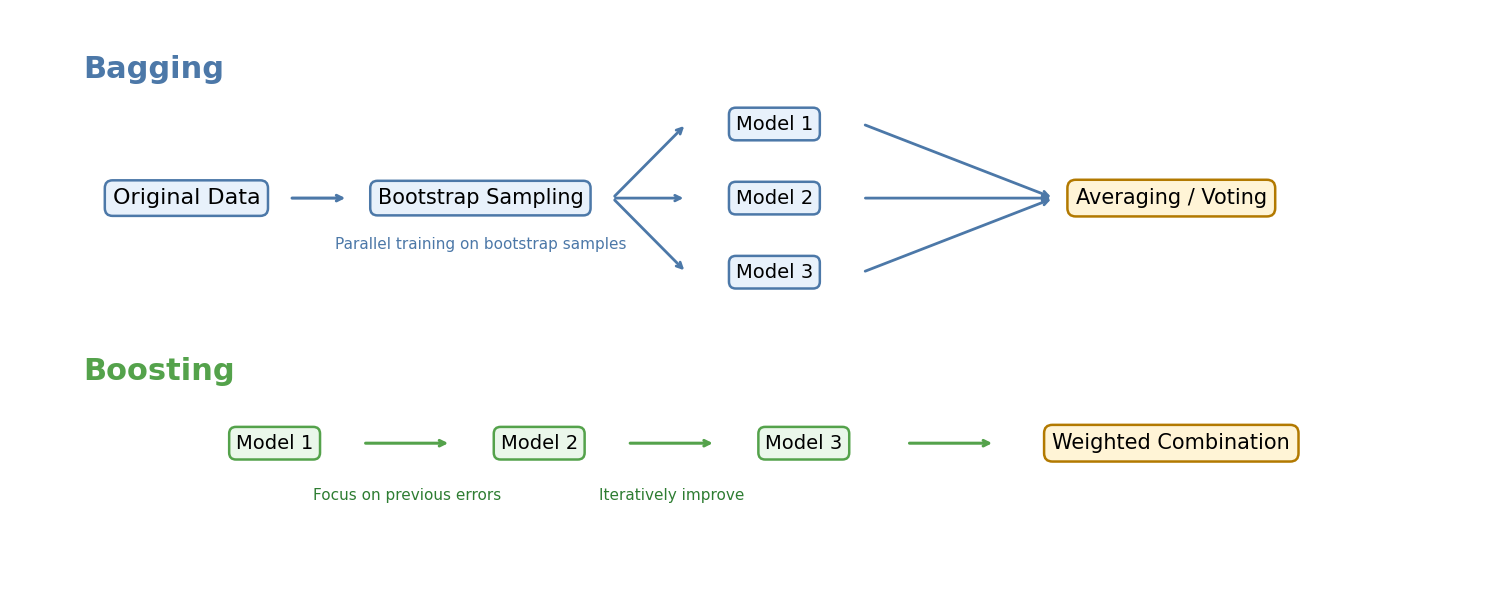

In [2]:
# Bagging vs Boosting: Simple Workflow Diagram

fig, ax = plt.subplots(figsize=(15, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

# Common box style
bag_box = dict(boxstyle="round,pad=0.35", fc="#E8F1FB", ec="#4C78A8", lw=1.8)
boost_box = dict(boxstyle="round,pad=0.35", fc="#EAF7EA", ec="#54A24B", lw=1.8)
final_box = dict(boxstyle="round,pad=0.4", fc="#FFF4D6", ec="#B27900", lw=1.8)

# -------------------------
# Bagging
# -------------------------
ax.text(0.05, 0.88, "Bagging", fontsize=22, weight="bold", color="#4C78A8")

ax.text(0.12, 0.67, "Original Data", fontsize=16,
        bbox=bag_box, ha="center", va="center")

ax.annotate("", xy=(0.23, 0.67), xytext=(0.19, 0.67),
            arrowprops=dict(arrowstyle="->", lw=2.2, color="#4C78A8"))

ax.text(0.32, 0.67, "Bootstrap Sampling", fontsize=15,
        bbox=bag_box, ha="center", va="center")

# split to models
model_x = 0.52
model_ys = [0.80, 0.67, 0.54]

for i, y in enumerate(model_ys, start=1):
    ax.text(model_x, y, f"Model {i}", fontsize=14,
            bbox=bag_box, ha="center", va="center")
    ax.annotate("", xy=(model_x - 0.06, y), xytext=(0.41, 0.67),
                arrowprops=dict(arrowstyle="->", lw=2, color="#4C78A8"))

# combine outputs
combine_x, combine_y = 0.79, 0.67
for y in model_ys:
    ax.annotate("", xy=(combine_x - 0.08, combine_y), xytext=(model_x + 0.06, y),
                arrowprops=dict(arrowstyle="->", lw=2, color="#4C78A8"))

ax.text(combine_x, combine_y, "Averaging / Voting", fontsize=15,
        bbox=final_box, ha="center", va="center")

# small note
ax.text(0.32, 0.58, "Parallel training on bootstrap samples",
        fontsize=11, color="#4C78A8", ha="center")

# -------------------------
# Boosting
# -------------------------
ax.text(0.05, 0.35, "Boosting", fontsize=22, weight="bold", color="#54A24B")

boost_positions = [0.18, 0.36, 0.54]
boost_y = 0.24

for i, x in enumerate(boost_positions, start=1):
    ax.text(x, boost_y, f"Model {i}", fontsize=14,
            bbox=boost_box, ha="center", va="center")

# sequential arrows
ax.annotate("", xy=(0.30, boost_y), xytext=(0.24, boost_y),
            arrowprops=dict(arrowstyle="->", lw=2.2, color="#54A24B"))
ax.annotate("", xy=(0.48, boost_y), xytext=(0.42, boost_y),
            arrowprops=dict(arrowstyle="->", lw=2.2, color="#54A24B"))
ax.annotate("", xy=(0.67, boost_y), xytext=(0.61, boost_y),
            arrowprops=dict(arrowstyle="->", lw=2.2, color="#54A24B"))

ax.text(0.79, boost_y, "Weighted Combination", fontsize=15,
        bbox=final_box, ha="center", va="center")

# notes below arrows
ax.text(0.27, 0.14, "Focus on previous errors", fontsize=11,
        color="#2E7D32", ha="center")
ax.text(0.45, 0.14, "Iteratively improve", fontsize=11,
        color="#2E7D32", ha="center")

plt.tight_layout()
plt.show()

>Bagging reduces variance through parallel model averaging, while Boosting reduces bias by sequentially focusing on misclassified samples.

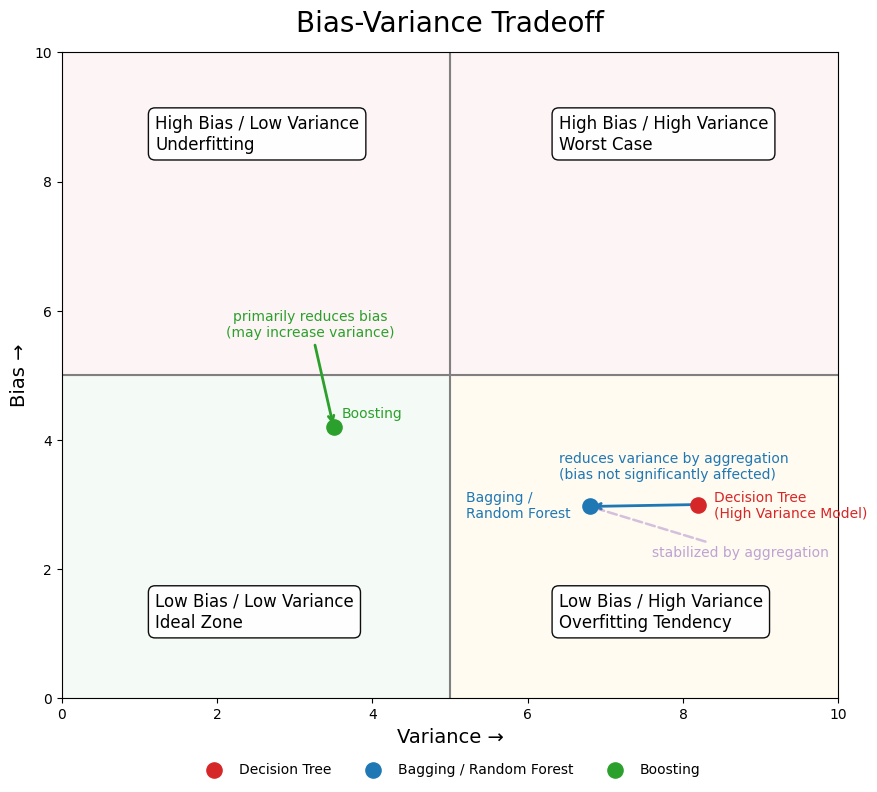

In [126]:
# Bias-Variance Quadrant Diagram (Conceptual)

fig, ax = plt.subplots(figsize=(9, 8))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)

# Quadrant lines
ax.axhline(5, color="gray", linewidth=1.5)
ax.axvline(5, color="gray", linewidth=1.5)

# Background colors for quadrants
ax.fill_between([0, 5], 5, 10, color="#f8d7da", alpha=0.25)   # High Bias / Low Variance
ax.fill_between([5, 10], 5, 10, color="#f5c6cb", alpha=0.18)  # High Bias / High Variance
ax.fill_between([0, 5], 0, 5, color="#d4edda", alpha=0.25)    # Low Bias / Low Variance
ax.fill_between([5, 10], 0, 5, color="#fff3cd", alpha=0.28)   # Low Bias / High Variance

ax.set_xlabel("Variance →", fontsize=14)
ax.set_ylabel("Bias →", fontsize=14)
ax.set_title("Bias-Variance Tradeoff", fontsize=20, pad=15)

# Quadrant labels
box_kw = dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.95)

ax.text(1.2, 8.5, "High Bias / Low Variance\nUnderfitting",
        fontsize=12, bbox=box_kw)

ax.text(6.4, 8.5, "High Bias / High Variance\nWorst Case",
        fontsize=12, bbox=box_kw)

ax.text(1.2, 1.1, "Low Bias / Low Variance\nIdeal Zone",
        fontsize=12, bbox=box_kw)

ax.text(6.4, 1.1, "Low Bias / High Variance\nOverfitting Tendency",
        fontsize=12, bbox=box_kw)

# Model points
decision_tree = (8.2, 3.0)
bagging_point = (6.8, 2.97)     # move left: lower variance
boosting_point = (3.5, 4.2)    # conceptual point

ax.scatter(*decision_tree, s=120, color="tab:red", zorder=5, label="Decision Tree")
ax.scatter(*bagging_point, s=120, color="tab:blue", zorder=5, label="Bagging / Random Forest")
ax.scatter(*boosting_point, s=120, color="tab:green", zorder=5, label="Boosting")

# Labels for points
ax.text(8.4, 2.8, "Decision Tree \n(High Variance Model)", fontsize=10, color="tab:red")
ax.text(5.2, 2.8, "Bagging / \nRandom Forest", fontsize=10, color="tab:blue")
ax.text(3.6, 4.35, "Boosting", fontsize=10, color="tab:green")

# Arrows showing direction
# Bagging: reduce variance -> move left
ax.annotate("",
            xy=bagging_point, xytext=(8.2, 3.0),
            ha="center",
            color="tab:blue",
            fontsize=10,
            arrowprops=dict(arrowstyle="->", lw=2, color="tab:blue"))

ax.text(6.4, 3.4, "reduces variance by aggregation \n(bias not significantly affected)", fontsize=10, color="tab:blue")

# Boosting: reduce bias -> move down
ax.annotate("primarily reduces bias\n(may increase variance)",
            xy=boosting_point, xytext=(3.2, 5.6),
            ha="center",
            color="tab:green",
            fontsize=10,
            arrowprops=dict(arrowstyle="->", lw=2, color="tab:green"))

# Optional guide arrow: from Decision Tree to Bagging
ax.annotate("stabilized by aggregation",
            xy=bagging_point, xytext=(7.6, 2.2),
            color="tab:purple",
            fontsize=10,
            alpha=0.6,
            arrowprops=dict(arrowstyle="-", lw=1.8, ls="--", color="tab:purple", alpha=0.4))


ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)
plt.tight_layout()
plt.show()

>Bagging moves models horizontally (reducing variance), while Boosting moves models vertically (reducing bias).   
>Bagging operates on unstable models (like decision trees) by averaging them to reduce variance, without significantly changing bias.
>Decision Trees usually have low bias because they can create highly flexible decision boundaries by recursively partitioning the feature space.  
>Random Forest slightly increases bias per tree, but aggregation compensates for it, resulting in similar or even lower overall bias.  
>Random Forest mainly reduces variance through averaging multiple decorrelated trees, while keeping bias roughly unchanged.  
>Boosting primarily reduces bias, but **may increase variance**, especially in the presence of noisy data.

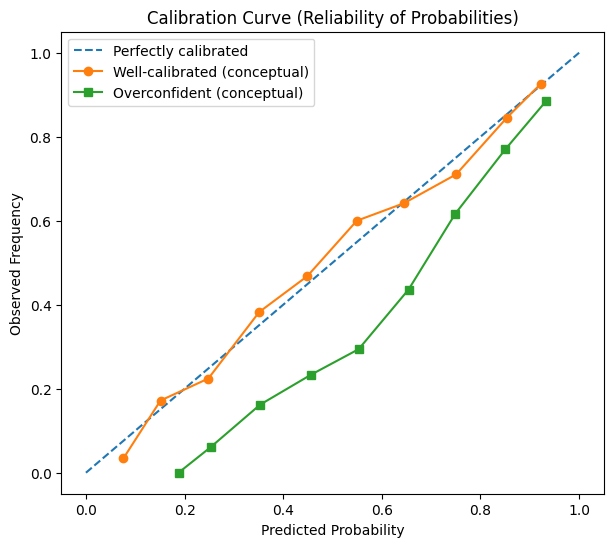

In [5]:
# Calibration Curve (Conceptual Example)

# Simulated probabilities:
# - One set close to well-calibrated
# - One set overconfident

rng = np.random.RandomState(42)
n = 1000

p_good = rng.uniform(0.05, 0.95, size=n)
y_good = rng.binomial(1, p_good)

p_over = np.clip(p_good ** 0.6, 0, 1)   # Overestimated probabilities
y_over = rng.binomial(1, p_good)

from sklearn.calibration import calibration_curve

frac_good, mean_good = calibration_curve(y_good, p_good, n_bins=10, strategy="uniform")
frac_over, mean_over = calibration_curve(y_over, p_over, n_bins=10, strategy="uniform")

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot([0, 1], [0, 1], linestyle="--", label="Perfectly calibrated")
ax.plot(mean_good, frac_good, marker="o", label="Well-calibrated (conceptual)")
ax.plot(mean_over, frac_over, marker="s", label="Overconfident (conceptual)")

ax.set_xlabel("Predicted Probability")
ax.set_ylabel("Observed Frequency")
ax.set_title("Calibration Curve (Reliability of Probabilities)")

ax.legend()
plt.show()

>A well-calibrated model produces probabilities that match the true likelihood of outcomes.
>For example, among all samples predicted with probability 0.8, approximately 80% should be positive.
>
>Overconfident models tend to predict probabilities that are too extreme, deviating from the diagonal line.
>
>Calibration is especially important for methods like soft voting, where predicted probabilities are averaged across models.

## 19. 更新後的面試版總結

你可以把整份筆記濃縮成下面幾句：

- **Bagging**：用 bootstrap 抽樣訓練多個獨立模型，最後平均 / 投票，主要降低 variance。  
- **Random Forest**：Bagging 的代表模型，以 Decision Tree 為基學習器，額外加入隨機選特徵。  
- **Boosting**：後面的模型持續修正前面的錯誤，主要降低 bias，但對 noise 比較敏感。  
- **Voting**：把多個模型的預測整合起來，可以是 heterogeneous models。  
- **Soft voting**：平均各模型機率，因此更依賴模型是否 well-calibrated。  
- **Stacking**：再訓練一個 meta model，學習怎麼整合前面多個模型的輸出。  

### 最後一句
> **Bagging reduces variance, Boosting reduces bias, Voting combines opinions, and Stacking learns how to combine them.**

## 20. 之後你可以繼續延伸的方向
- `RandomForestClassifier` / `RandomForestRegressor` 參數解析
- `XGBoost` 與 `LightGBM` 的差異
- `StackingClassifier` / `StackingRegressor` 的實作方式
- bias / variance 與 ensemble 的關係